In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [4]:
from src.preprocessing.dataset_loader import (
    build_dataset_index,
    ChestXRayDataset
)

In [5]:
train_paths, train_labels = build_dataset_index(
    "../data/raw/train"
)

print("Images:", len(train_paths))
print("Labels:", len(train_labels))

Images: 5216
Labels: 5216


In [6]:
from src.preprocessing.splitter import (
    create_stratified_split
)

(
    X_train,
    X_val,
    y_train,
    y_val
) = create_stratified_split(
    train_paths,
    train_labels
)

print("Train:", len(X_train))
print("Validation:", len(X_val))

Train: 4172
Validation: 1044


In [7]:
from src.preprocessing.transforms import (
    train_transform,
    val_transform
)

train_dataset = ChestXRayDataset(
    X_train,
    y_train,
    transform=train_transform
)

val_dataset = ChestXRayDataset(
    X_val,
    y_val,
    transform=val_transform
)

In [8]:
print(len(train_dataset))
print(len(val_dataset))

4172
1044


In [9]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
0


In [10]:
print(image.min())
print(image.max())

tensor(-1.)
tensor(0.9765)


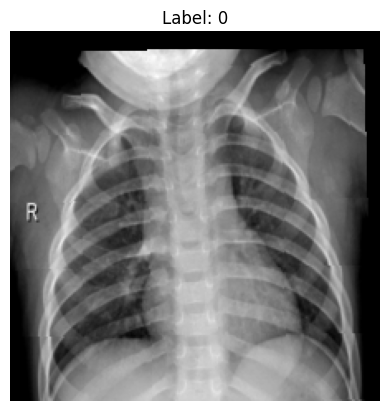

In [11]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

image = image.permute(
    1,
    2,
    0
)

image = (
    image * 0.5
) + 0.5

plt.imshow(image.numpy())
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()